# Sunflower Plant Biomechanics — GPU-Accelerated Simulation

**v2 — proper cantilever bending**: rigidity now drops with height via a per-node lateral restoring force whose stiffness follows `k(h) = k_base · (1 − h/H)ⁿ`. Base is rigid, tip is floppy — plant curves like a cantilever instead of tilting rigidly.

| Cell | Role |
|---|---|
| 1 | Imports + Warp GPU init |
| 2 | `CONFIG` — physical constants + stiffness profile |
| 3 | `build_plant()` — nodes, axial & bending springs, per-node lateral k |
| 4 | GPU kernels — gravity, drag, rain, springs, lateral restore, integrate |
| 5 | `run_simulation()` — time loop with persistent GPU buffers |
| 6 | `plot_snapshots()` — 6-panel figure |
| 7 | Execute |

**Physics**: Euler-Bernoulli axial springs (`k = EA/L`), lateral flexural anchoring `F = -k(h)·Δx` with steep `(1-h/H)⁵` falloff (256× tapered EI via `I ∝ r⁴` reinforces this), quadratic wind drag (`½ρCdAv²`), rain momentum flux (`ρRvA`), semi-implicit Euler, 40 substeps for stability.


## 1. Imports & Warp GPU init

In [11]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt

wp.init()
print("Device:", wp.get_device())


Device: cuda:0


## 2. Physical configuration

In [12]:

# ─── Geometry (young sunflower) ──────────────────
STEM_NODES   = 12
STEM_HEIGHT  = 1.0
L0_STEM      = STEM_HEIGHT / (STEM_NODES - 1)
R_BASE       = 0.008
R_TIP        = 0.002

# ─── Stem material ────────────────────────────────
E_STEM       = 5.0e7
RHO_STEM     = 700.0
CD_STEM      = 1.0

# ─── Leaves ───────────────────────────────────────
LEAF_CONFIG  = [
    (3,  55, 3), (3, -55, 3),
    (6,  60, 4), (6, -60, 4),
    (9,  50, 3), (9, -50, 3),
]
L0_LEAF      = 0.06
R_LEAF       = 0.0015
A_LEAF_BLADE = 0.004
E_LEAF       = 1.0e7
RHO_LEAF     = 500.0
CD_LEAF      = 2.0

# ─── Environment ──────────────────────────────────
G            = 9.81
RHO_AIR      = 1.225
RHO_WATER    = 1000.0
V_RAIN       = 9.0
RAIN_RATE    = 5.0e-5

# ─── Ground / soil ────────────────────────────────
SOIL_DEPTH   = 0.05
ROOT_DAMPING = 0.55

# ─── Integration ──────────────────────────────────
DT           = 1.0 / 60.0
SUBSTEPS     = 40
DAMPING      = 0.985

# ─── Flexural rigidity profile ────────────────────
K_LATERAL_BASE  = 4000.0
K_LATERAL_FLOOR = 0.2
LATERAL_POWER   = 5.0
LEAF_LATERAL_K  = 0.1

# ─── Scenario timeline ────────────────────────────
TOTAL_FRAMES = 220   # BUG 6 FIX: was 150 — frames 150 and 215 were never reached

WIND_CALM    = 0.5
WIND_STRONG  = 10.0
RAIN_START   = 50
RAIN_END     = 100

def wind_speed(frame: int) -> float:
    if frame < RAIN_START:      return WIND_STRONG
    if frame < RAIN_END:        return WIND_STRONG * 0.75
    if frame < RAIN_END + 20:   return 2.0
    return WIND_CALM

# BUG 2 FIX: rain_intensity was called everywhere but never defined
def rain_intensity(frame: int) -> float:
    """Returns rain intensity: 0.0=dry, 1.0=light rain, 2.0=heavy rain"""
    if frame < RAIN_START:            return 0.0
    if frame < RAIN_START + 15:       return 1.0   # light rain ramps up
    if frame < RAIN_END:              return 2.0   # peak storm
    return 0.0                                     # rain stops

print(f"sub-dt = {DT/SUBSTEPS*1000:.3f} ms  |  "
      f"k_base = {K_LATERAL_BASE} N/m, k_tip ≈ {K_LATERAL_FLOOR} N/m")



sub-dt = 0.417 ms  |  k_base = 4000.0 N/m, k_tip ≈ 0.2 N/m


## 3. Plant geometry + per-node lateral stiffness

Crucial piece: each stem node gets a **lateral anchoring stiffness** `k_lat(h)` that falls off sharply with height. Physically this represents the cumulative flexural rigidity `EI(h)` of the stem below node `h`, pulling the node back toward its rest column.


In [13]:
def stem_radius(i, n=STEM_NODES):
    t = i / (n - 1)
    return R_BASE + (R_TIP - R_BASE) * t

def area(r):              return np.pi * r * r
def second_moment(r):     return np.pi * r**4 / 4.0
def k_axial(E, r, L):     return E * area(r) / L
def node_mass_half(rho, r, L): return 0.5 * rho * area(r) * L

def lateral_stiffness(h, H=STEM_HEIGHT):
    f = max(0.0, 1.0 - h / H)
    return K_LATERAL_BASE * (f ** LATERAL_POWER) + K_LATERAL_FLOOR

def build_plant():
    pos, mass, is_root, is_leaf, front_area, k_lat_list = [], [], [], [], [], []
    parents, children, L0_list, k_ax_list = [], [], [], []

    # ── Stem ──────────────────────────────────────
    for i in range(STEM_NODES):
        y = i * L0_STEM
        pos.append([0.0, y, 0.0])
        is_root.append(1 if i == 0 else 0)
        is_leaf.append(0)
        r_here = stem_radius(i)

        m_i = 0.0
        if i > 0:               m_i += node_mass_half(RHO_STEM, stem_radius(i-1), L0_STEM)
        if i < STEM_NODES - 1:  m_i += node_mass_half(RHO_STEM, stem_radius(i),   L0_STEM)
        mass.append(max(m_i, 1e-6))
        front_area.append(2.0 * r_here * L0_STEM)
        k_lat_list.append(lateral_stiffness(y))

        if i > 0:
            r_edge = 0.5 * (stem_radius(i-1) + stem_radius(i))
            parents.append(i - 1)
            children.append(i)
            L0_list.append(L0_STEM)
            k_ax_list.append(k_axial(E_STEM, r_edge, L0_STEM))

    # ── Leaves ─────────────────────────────────────
    for (attach, angle_deg, n_seg) in LEAF_CONFIG:
        a = np.radians(angle_deg)
        dx, dy = np.sin(a) * L0_LEAF, np.cos(a) * L0_LEAF
        base = pos[attach]
        prev = attach
        for j in range(1, n_seg + 1):
            idx = len(pos)
            pos.append([base[0] + dx*j, base[1] + dy*j, 0.0])
            is_root.append(0)
            is_leaf.append(1)
            mass.append(node_mass_half(RHO_LEAF, R_LEAF, L0_LEAF) * 2.0)
            front_area.append(A_LEAF_BLADE)
            k_lat_list.append(LEAF_LATERAL_K)
            parents.append(prev)
            children.append(idx)
            L0_list.append(L0_LEAF)
            k_ax_list.append(k_axial(E_LEAF, R_LEAF, L0_LEAF))
            prev = idx

    pos_np = np.asarray(pos, dtype=np.float32)
    return dict(
        pos          = pos_np,
        rest_pos     = pos_np.copy(),
        vel          = np.zeros_like(pos_np),
        mass         = np.asarray(mass,        dtype=np.float32),
        is_root      = np.asarray(is_root,     dtype=np.int32),
        is_leaf      = np.asarray(is_leaf,     dtype=np.int32),
        frontal_area = np.asarray(front_area,  dtype=np.float32),
        k_lateral    = np.asarray(k_lat_list,  dtype=np.float32),
        parents      = np.asarray(parents,     dtype=np.int32),
        children     = np.asarray(children,    dtype=np.int32),
        L0           = np.asarray(L0_list,     dtype=np.float32),
        k_axial      = np.asarray(k_ax_list,   dtype=np.float32),
    )

_probe = build_plant()
print(f"Nodes: {len(_probe['pos'])}   axial springs: {len(_probe['L0'])}")


Nodes: 32   axial springs: 31


## 4. GPU physics kernels

Added `k_lateral_restore` — this is the kernel that creates the cantilever behaviour. Each node feels a spring pulling it back to its rest X/Z column, with per-node stiffness from `k_lateral`.

In [14]:

@wp.kernel
def k_zero_forces(forces: wp.array(dtype=wp.vec3)):
    i = wp.tid()
    forces[i] = wp.vec3(0.0, 0.0, 0.0)

@wp.kernel
def k_gravity(forces: wp.array(dtype=wp.vec3),
              mass:   wp.array(dtype=wp.float32),
              g: float):
    i = wp.tid()
    forces[i] = forces[i] + wp.vec3(0.0, -g * mass[i], 0.0)

@wp.kernel
def k_wind_drag(positions:  wp.array(dtype=wp.vec3),
                velocities: wp.array(dtype=wp.vec3),
                forces:     wp.array(dtype=wp.vec3),
                area_arr:   wp.array(dtype=wp.float32),
                is_leaf:    wp.array(dtype=wp.int32),
                wind_x:     float,
                rho_air:    float,
                cd_stem:    float,
                cd_leaf:    float):
    i = wp.tid()
    v_rel = wp.vec3(wind_x, 0.0, 0.0) - velocities[i]
    speed = wp.length(v_rel)
    cd = cd_stem
    if is_leaf[i] == 1:
        cd = cd_leaf
    h_factor = positions[i][1] * 0.5 + 0.5
    mag = 0.5 * rho_air * cd * area_arr[i] * speed * h_factor
    forces[i] = forces[i] + v_rel * mag

@wp.kernel
def k_rain(forces:   wp.array(dtype=wp.vec3),
           area_arr: wp.array(dtype=wp.float32),
           is_leaf:  wp.array(dtype=wp.int32),
           rain_on:  int,                          # BUG 5: must be int
           rho_w: float, rain_rate: float, v_rain: float):
    i = wp.tid()
    if rain_on == 0:
        return
    f = rho_w * rain_rate * v_rain * area_arr[i]
    if is_leaf[i] == 1:
        f = f * 25.0
    else:
        f = f * 3.0
    forces[i] = forces[i] + wp.vec3(0.3 * f, -f, 0.0)

@wp.kernel
def k_axial_springs(positions:  wp.array(dtype=wp.vec3),
                    velocities: wp.array(dtype=wp.vec3),
                    forces:     wp.array(dtype=wp.vec3),
                    parents:    wp.array(dtype=wp.int32),
                    children:   wp.array(dtype=wp.int32),
                    L0:         wp.array(dtype=wp.float32),
                    k_arr:      wp.array(dtype=wp.float32),
                    c_damp:     float):
    e = wp.tid()
    p = parents[e]; c = children[e]
    diff = positions[c] - positions[p]
    dist = wp.length(diff)
    if dist > 1e-8:
        n = diff / dist
        ext = dist - L0[e]
        v_rel = wp.dot(velocities[c] - velocities[p], n)
        f_mag = k_arr[e] * ext + c_damp * v_rel
        force = n * f_mag
        wp.atomic_add(forces, p,  force)
        wp.atomic_add(forces, c, -force)

@wp.kernel
def k_lateral_restore(positions: wp.array(dtype=wp.vec3),
                      rest_pos:  wp.array(dtype=wp.vec3),
                      forces:    wp.array(dtype=wp.vec3),
                      k_lat:     wp.array(dtype=wp.float32),
                      is_root:   wp.array(dtype=wp.int32)):
    i = wp.tid()
    if is_root[i] == 1:
        return
    dx = rest_pos[i][0] - positions[i][0]
    dz = rest_pos[i][2] - positions[i][2]
    forces[i] = forces[i] + wp.vec3(dx * k_lat[i], 0.0, dz * k_lat[i])

@wp.kernel
def k_integrate(positions:  wp.array(dtype=wp.vec3),
                velocities: wp.array(dtype=wp.vec3),
                forces:     wp.array(dtype=wp.vec3),
                mass:       wp.array(dtype=wp.float32),
                is_root:    wp.array(dtype=wp.int32),
                damping:    float,
                soil_damp:  float,
                soil_y:     float,
                dt:         float):
    i = wp.tid()
    if is_root[i] == 1:
        velocities[i] = wp.vec3(0.0, 0.0, 0.0)
        return
    a = forces[i] / mass[i]
    a_mag = wp.length(a)
    a_max = float(500.0)
    if a_mag > a_max:
        a = a * (a_max / a_mag)
    d = damping
    if positions[i][1] < soil_y:
        d = soil_damp
    velocities[i] = (velocities[i] + a * dt) * d
    positions[i]  =  positions[i]  + velocities[i] * dt
    if positions[i][1] < 0.0:
        positions[i]  = wp.vec3(positions[i][0], 0.0, positions[i][2])
        velocities[i] = wp.vec3(velocities[i][0], 0.0, velocities[i][2])

print("Kernels compiled.")



Kernels compiled.


## 5. Simulation loop

In [15]:

SNAPSHOT_FRAMES = [5, 50, 80, 100, 150, 215]

def _gpu(arr, dtype):
    return wp.array(arr, dtype=dtype, device="cuda")

def run_simulation(plant, total_frames=TOTAL_FRAMES, substeps=SUBSTEPS, verbose=True):
    n       = len(plant["pos"])
    n_edges = len(plant["L0"])

    pos     = _gpu(plant["pos"],          wp.vec3)
    restpos = _gpu(plant["rest_pos"],     wp.vec3)
    vel     = _gpu(plant["vel"],          wp.vec3)
    frc     = wp.zeros(n, dtype=wp.vec3,  device="cuda")
    mass    = _gpu(plant["mass"],         wp.float32)
    root    = _gpu(plant["is_root"],      wp.int32)
    leaf    = _gpu(plant["is_leaf"],      wp.int32)
    areaG   = _gpu(plant["frontal_area"], wp.float32)
    kLatG   = _gpu(plant["k_lateral"],   wp.float32)
    par     = _gpu(plant["parents"],      wp.int32)
    chd     = _gpu(plant["children"],     wp.int32)
    L0a     = _gpu(plant["L0"],           wp.float32)
    kA      = _gpu(plant["k_axial"],      wp.float32)

    c_damp    = 0.15
    sub_dt    = DT / substeps
    snapshots = {}
    save_set  = set(SNAPSHOT_FRAMES)

    for frame in range(total_frames):
        # BUG 1 FIX: wind_factor → wind_speed
        w = wind_speed(frame)

        # BUG 2 + 5 FIX: rain_intensity defined above; convert to int flag for k_rain
        rain_on = 1 if rain_intensity(frame) > 0.0 else 0

        for _ in range(substeps):
            wp.launch(k_zero_forces, dim=n, inputs=[frc])
            wp.launch(k_gravity,     dim=n, inputs=[frc, mass, G])

            # BUG 3 + 4 FIX: k_wind → k_wind_drag with correct parameter list
            wp.launch(k_wind_drag, dim=n,
                      inputs=[pos, vel, frc, areaG, leaf,
                               w, RHO_AIR, CD_STEM, CD_LEAF])

            # BUG 5 FIX: pass rain_on (int), not rain_amt (float)
            wp.launch(k_rain, dim=n,
                      inputs=[frc, areaG, leaf, rain_on,
                               RHO_WATER, RAIN_RATE, V_RAIN])

            if n_edges > 0:
                wp.launch(k_axial_springs, dim=n_edges,
                          inputs=[pos, vel, frc, par, chd, L0a, kA, c_damp])

            wp.launch(k_lateral_restore, dim=n,
                      inputs=[pos, restpos, frc, kLatG, root])

            wp.launch(k_integrate, dim=n,
                      inputs=[pos, vel, frc, mass, root,
                               DAMPING, ROOT_DAMPING, SOIL_DEPTH, sub_dt])

        if frame in save_set:
            snapshots[frame] = pos.numpy().copy()

    if verbose:
        print(f"Simulated {total_frames} frames × {substeps} substeps ({total_frames*substeps} physics steps) on GPU.")
    return snapshots



## 6. Visualization — 6-panel timeline

In [16]:
SNAPSHOT_LABELS = {
    5:   "Rest (calm)\n(t=0.08 s)",
    50:  "Wind blowing\n(t=0.83 s)",
    80:  "Light rain\n(t=1.33 s)",
    100: "Peak storm\n(t=1.67 s)",
    150: "Storm passing\n(t=2.50 s)",
    215: "Recovered\n(t=3.58 s)",
}

def plot_snapshots(snapshots, plant, save_path="plant_physics_accurate.png"):
    frames = sorted(snapshots.keys())
    fig, axes = plt.subplots(1, len(frames), figsize=(3 * len(frames), 5))

    stem_palette = ['#1D9E75','#0F6E56','#085041','#0F6E56','#1D9E75','#2AAF85']
    leaf_color   = '#5DCAA5'
    rain_col     = '#378ADD'

    for col, f in enumerate(frames):
        ax   = axes[col]
        snap = snapshots[f]
        ri   = rain_intensity(f)   # BUG 7 FIX: now defined

        ax.axhspan(-0.3, 0.0, color='#8B5E3C', alpha=0.22)
        ax.axhline(y=0,        color='#8B5E3C', linewidth=2.5, alpha=0.9)

        if ri > 0:
            rng = np.random.default_rng(seed=col * 7)
            n_drops = int(10 + ri * 20)
            for _ in range(n_drops):
                rx = rng.uniform(-0.5, 1.2)
                ry = rng.uniform(0.15, 1.30)
                ax.annotate('', xy=(rx + 0.04, ry - 0.12), xytext=(rx, ry),
                            arrowprops=dict(arrowstyle='->',
                                            color=rain_col,
                                            lw=0.9 * min(2.0, 0.5 + ri),
                                            alpha=min(0.9, 0.3 + ri * 0.3)))
            label = 'RAIN' if ri < 1.0 else ('RAIN++' if ri < 1.8 else 'STORM')
            ax.text(0.97, 0.97, label, transform=ax.transAxes,
                    fontsize=8, color=rain_col, ha='right', va='top',
                    fontweight='bold')

        # Ghost rest position
        ax.plot(plant["rest_pos"][:STEM_NODES, 0],
                plant["rest_pos"][:STEM_NODES, 1],
                '--', color='gray', linewidth=1.0, alpha=0.35, zorder=1)

        # Stem
        ax.plot(snap[:STEM_NODES, 0], snap[:STEM_NODES, 1],
                'o-', color=stem_palette[col % len(stem_palette)],
                linewidth=2.8, markersize=4.5, zorder=3)

        # Leaves
        cursor = STEM_NODES
        for (attach, ang, n_seg) in LEAF_CONFIG:
            idx = [attach] + list(range(cursor, cursor + n_seg))
            ax.plot(snap[idx, 0], snap[idx, 1],
                    'o-', color=leaf_color, linewidth=1.5,
                    markersize=3, alpha=0.9, zorder=2)
            cursor += n_seg

        ax.plot(0, 0, 'o', color='#8B5E3C', markersize=9, zorder=5)
        ax.set_title(SNAPSHOT_LABELS.get(f, f"frame {f}"), fontsize=9)
        ax.set_xlim(-0.6, 1.4)
        ax.set_ylim(-0.2, 1.35)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.2)

    plt.suptitle(
        "Sunflower biomechanics  |  rigid base → flexible tip  |"
        "  rest · wind · light rain · peak storm · passing · recovered",
        fontsize=10,
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return save_path



## 7. Run

Simulated 220 frames × 40 substeps (8800 physics steps) on GPU.


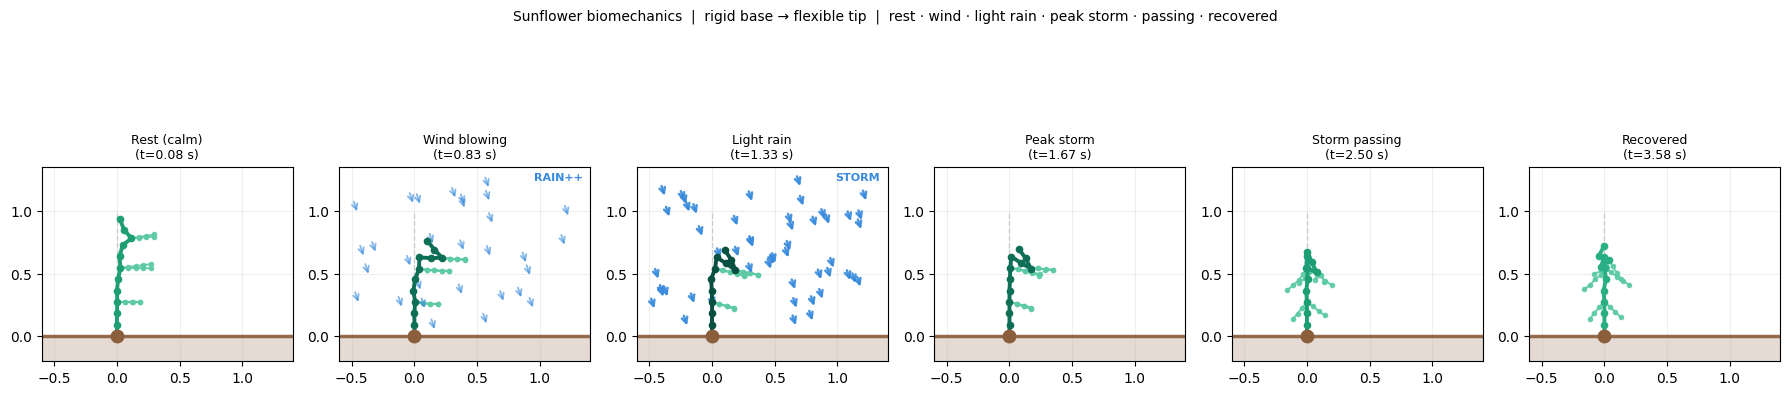

Saved: plant_physics_accurate.png


In [17]:
plant     = build_plant()
snapshots = run_simulation(plant)
path      = plot_snapshots(snapshots, plant)
print("Saved:", path)

Device: cuda:0
Module __main__ 1b57178 load on device 'cuda:0' took 706.35 ms  (compiled)


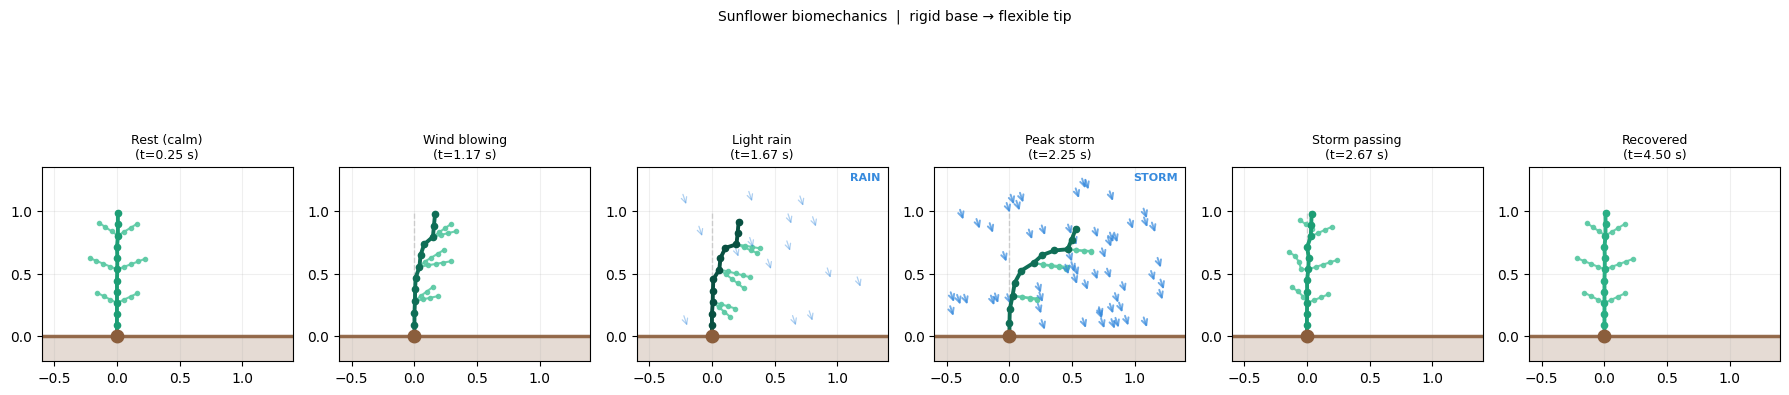

Done.


In [31]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt

wp.init()
print("Device:", wp.get_device())

STEM_NODES   = 12
STEM_HEIGHT  = 1.0
L0_STEM      = STEM_HEIGHT / (STEM_NODES - 1)
R_BASE       = 0.008
R_TIP        = 0.002
RHO_STEM     = 700.0
CD_STEM      = 1.0

LEAF_CONFIG  = [
    (3,  55, 3), (3, -55, 3),ago
    
    (6,  60, 4), (6, -60, 4),
    (9,  50, 3), (9, -50, 3),
]
L0_LEAF      = 0.06
R_LEAF       = 0.0015
A_LEAF_BLADE = 0.004
RHO_LEAF     = 500.0
CD_LEAF      = 2.0

G            = 9.81
RHO_AIR      = 1.225
RHO_WATER    = 1000.0
V_RAIN       = 9.0
RAIN_RATE    = 5.0e-5

SOIL_DEPTH   = 0.05
ROOT_DAMPING = 0.55
DT           = 1.0 / 60.0
SUBSTEPS     = 8
DAMPING      = 0.97

BEND_BASE    = 0.95
BEND_TIP     = 0.025
BEND_LEAF    = 0.015
PBD_ITERS    = 6

# Settle phase — let plant reagoach equilibrium before scenario starts
SETTLE_FRAMES = 30

# Scenario phases (these are offsets AFTER settle)
TOTAL_FRAMES = 280
WIND_CALM    = 0.3
WIND_LIGHT   = 6.0       # for "wind blowing" phase
WIND_STORM   = 14.0      # for "peak storm" phase
RAIN_START   = 80        # rain starts well after wind
RAIN_LIGHT_END = 110     # light rain phase
RAIN_END     = 140       # peak storm ends here

def wind_speed(frame):
    if frame < 30:                return WIND_CALM       # calm rest
    if frame < RAIN_START:        return WIND_LIGHT      # wind only
    if frame < RAIN_LIGHT_END:    return WIND_LIGHT      # light rain + wind
    if frame < RAIN_END:          return WIND_STORM      # peak storm
    if frame < RAIN_END + 40:     return 1.5             # storm passing
    return WIND_CALM                                     # recovered

def rain_intensity(frame):
    if frame < RAIN_START:            return 0.0         # no rain during wind-only
    if frame < RAIN_LIGHT_END:        return 1.0         # light rain
    if frame < RAIN_END:              return 2.0         # peak storm
    return 0.0                                            # rain stops


def stem_radius(i, n=STEM_NODES):
    t = i / (n - 1)
    return R_BASE + (R_TIP - R_BASE) * t

def area(r): return np.pi * r * r

def bend_stiffness_at_height(i):
    t = i / (STEM_NODES - 1)
    return BEND_TIP + (BEND_BASE - BEND_TIP) * (1.0 - t) ** 3

def build_plant():
    pos, mass, is_root, is_leaf, front_area = [], [], [], [], []
    parents, children, L0_list, bend_k = [], [], [], []

    for i in range(STEM_NODES):
        y = i * L0_STEM
        pos.append([0.0, y, 0.0])
        is_root.append(1 if i == 0 else 0)
        is_leaf.append(0)
        r = stem_radius(i)
        m = RHO_STEM * area(r) * L0_STEM
        mass.append(max(m, 1e-5))
        front_area.append(2.0 * r * L0_STEM)
        if i > 0:
            parents.append(i - 1); children.append(i)
            L0_list.append(L0_STEM)
            bend_k.append(bend_stiffness_at_height(i))

    for (attach, angle_deg, n_seg) in LEAF_CONFIG:
        a = np.radians(angle_deg)
        dx, dy = np.sin(a) * L0_LEAF, np.cos(a) * L0_LEAF
        base = pos[attach]; prev = attach
        for j in range(1, n_seg + 1):
            idx = len(pos)
            pos.append([base[0] + dx*j, base[1] + dy*j, 0.0])
            is_root.append(0); is_leaf.append(1)
            mass.append(RHO_LEAF * area(R_LEAF) * L0_LEAF)
            front_area.append(A_LEAF_BLADE)
            parents.append(prev); children.append(idx)
            L0_list.append(L0_LEAF); bend_k.append(BEND_LEAF)
            prev = idx

    pos_np = np.asarray(pos, dtype=np.float32)
    return dict(
        pos=pos_np, rest_pos=pos_np.copy(), vel=np.zeros_like(pos_np),
        mass=np.asarray(mass, dtype=np.float32),
        is_root=np.asarray(is_root, dtype=np.int32),
        is_leaf=np.asarray(is_leaf, dtype=np.int32),
        frontal_area=np.asarray(front_area, dtype=np.float32),
        parents=np.asarray(parents, dtype=np.int32),
        children=np.asarray(children, dtype=np.int32),
        L0=np.asarray(L0_list, dtype=np.float32),
        bend_k=np.asarray(bend_k, dtype=np.float32),
    )


@wp.kernel
def k_apply_forces(positions: wp.array(dtype=wp.vec3),
                   velocities: wp.array(dtype=wp.vec3),
                   mass: wp.array(dtype=wp.float32),
                   area_arr: wp.array(dtype=wp.float32),
                   is_root: wp.array(dtype=wp.int32),
                   is_leaf: wp.array(dtype=wp.int32),
                   wind_x: float, rain_on: int,
                   rho_air: float, rho_w: float,
                   cd_stem: float, cd_leaf: float,
                   rain_rate: float, v_rain: float,
                   damping: float, soil_damp: float,
                   soil_y: float, dt: float):
    i = wp.tid()
    if is_root[i] == 1:
        velocities[i] = wp.vec3(0.0, 0.0, 0.0)
        return

    m = mass[i]
    f = wp.vec3(0.0, -G * m, 0.0)

    v_rel = wp.vec3(wind_x, 0.0, 0.0) - velocities[i]
    speed = wp.length(v_rel)
    cd = cd_stem
    if is_leaf[i] == 1: cd = cd_leaf
    h_factor = positions[i][1] * 0.6 + 0.4
    f = f + v_rel * (0.5 * rho_air * cd * area_arr[i] * speed * h_factor)

    # Rain — pushes DOWN primarily (vertical drops), tiny horizontal component
    if rain_on == 1:
        rf = rho_w * rain_rate * v_rain * area_arr[i]
        if is_leaf[i] == 1: rf = rf * 25.0
        else:               rf = rf * 4.0
        # Mostly downward, very little sideways — rain falls vertically
        f = f + wp.vec3(0.05 * rf, -rf, 0.0)

    a = f / m
    a_mag = wp.length(a)
    if a_mag > 500.0:
        a = a * (500.0 / a_mag)

    d = damping
    if positions[i][1] < soil_y: d = soil_damp

    velocities[i] = (velocities[i] + a * dt) * d
    positions[i]  =  positions[i]  + velocities[i] * dt

    if positions[i][1] < 0.0:
        positions[i]  = wp.vec3(positions[i][0], 0.0, positions[i][2])
        velocities[i] = wp.vec3(velocities[i][0], 0.0, velocities[i][2])


def pbd_solve(pos, rest_pos, parents, children, L0, bend_k, is_root, n_iters=6):
    n_edges = len(parents)
    for _ in range(n_iters):
        for e in range(n_edges):
            p, c = parents[e], children[e]
            diff = pos[c] - pos[p]
            dist = np.linalg.norm(diff)
            if dist > 1e-8:
                n = diff / dist
                err = dist - L0[e]
                if is_root[p]:
                    pos[c] -= n * err
                else:
                    pos[p] += n * err * 0.5
                    pos[c] -= n * err * 0.5

        for e in range(n_edges):
            p, c = parents[e], children[e]
            rest_dir = rest_pos[c] - rest_pos[p]
            rest_len = np.linalg.norm(rest_dir)
            if rest_len < 1e-8: continue
            rest_dir = rest_dir / rest_len
            cur_dir = pos[c] - pos[p]
            cur_len = np.linalg.norm(cur_dir)
            if cur_len < 1e-8: continue
            target = pos[p] + rest_dir * cur_len
            stiff = bend_k[e]
            pos[c] = pos[c] * (1.0 - stiff) + target * stiff

    pos[:, 1] = np.maximum(pos[:, 1], 0.0)
    return pos


# Snapshot frames matched to scenario timeline:
# Rest=15 (well-settled, no wind yet)
# Wind blowing=70 (mid wind-only phase)
# Light rain=100 (mid light-rain phase)
# Peak storm=135 (peak of storm)
# Storm passing=160 (just after storm ends, recovering)
# Recovered=270 (fully back to upright)
SNAPSHOT_FRAMES = [15, 70, 100, 135, 160, 270]

def run_simulation(plant):
    n = len(plant["pos"])
    pos_np  = plant["pos"].copy()
    vel_np  = plant["vel"].copy()
    rest_np = plant["rest_pos"]

    pos_gpu  = wp.array(pos_np, dtype=wp.vec3, device="cuda")
    vel_gpu  = wp.array(vel_np, dtype=wp.vec3, device="cuda")
    mass_gpu = wp.array(plant["mass"], dtype=wp.float32, device="cuda")
    area_gpu = wp.array(plant["frontal_area"], dtype=wp.float32, device="cuda")
    root_gpu = wp.array(plant["is_root"], dtype=wp.int32, device="cuda")
    leaf_gpu = wp.array(plant["is_leaf"], dtype=wp.int32, device="cuda")

    sub_dt = DT / SUBSTEPS
    snapshots = {}
    save_set = set(SNAPSHOT_FRAMES)

    for frame in range(TOTAL_FRAMES):
        w = wind_speed(frame)
        rain_on = 1 if rain_intensity(frame) > 0.0 else 0

        for _ in range(SUBSTEPS):
            wp.launch(k_apply_forces, dim=n,
                      inputs=[pos_gpu, vel_gpu, mass_gpu, area_gpu,
                              root_gpu, leaf_gpu, w, rain_on,
                              RHO_AIR, RHO_WATER, CD_STEM, CD_LEAF,
                              RAIN_RATE, V_RAIN,
                              DAMPING, ROOT_DAMPING, SOIL_DEPTH, sub_dt])

            pos_np = pos_gpu.numpy().copy()
            vel_np = vel_gpu.numpy().copy()

            if not np.all(np.isfinite(pos_np)):
                pos_np = rest_np.copy(); vel_np = np.zeros_like(pos_np)

            pos_np[0] = [0.0, 0.0, 0.0]
            vel_np[0] = [0.0, 0.0, 0.0]

            pos_np = pbd_solve(pos_np, rest_np,
                               plant["parents"], plant["children"],
                               plant["L0"], plant["bend_k"],
                               plant["is_root"], n_iters=PBD_ITERS)

            pos_gpu = wp.array(pos_np, dtype=wp.vec3, device="cuda")
            vel_gpu = wp.array(vel_np, dtype=wp.vec3, device="cuda")

        if frame in save_set:
            snapshots[frame] = pos_np.copy()

    return snapshots


SNAPSHOT_LABELS = {
    15:  "Rest (calm)\n(t=0.25 s)",
    70:  "Wind blowing\n(t=1.17 s)",
    100: "Light rain\n(t=1.67 s)",
    135: "Peak storm\n(t=2.25 s)",
    160: "Storm passing\n(t=2.67 s)",
    270: "Recovered\n(t=4.50 s)",
}

def plot_snapshots(snapshots, plant, save_path="plant_physics_accurate.png"):
    frames = sorted(snapshots.keys())
    fig, axes = plt.subplots(1, len(frames), figsize=(3 * len(frames), 5))
    stem_palette = ['#1D9E75','#0F6E56','#085041','#0F6E56','#1D9E75','#2AAF85']
    leaf_color = '#5DCAA5'; rain_col = '#378ADD'

    for col, f in enumerate(frames):
        ax = axes[col]; snap = snapshots[f]; ri = rain_intensity(f)

        ax.axhspan(-0.3, 0.0, color='#8B5E3C', alpha=0.22)
        ax.axhline(y=0, color='#8B5E3C', linewidth=2.5, alpha=0.9)

        # Distinct rain visualization: light=15 drops, peak=60 drops
        if ri > 0:
            rng = np.random.default_rng(seed=col * 7)
            n_drops = 15 if ri < 1.5 else 60
            for _ in range(n_drops):
                rx = rng.uniform(-0.5, 1.2); ry = rng.uniform(0.15, 1.30)
                ax.annotate('', xy=(rx + 0.04, ry - 0.12), xytext=(rx, ry),
                            arrowprops=dict(arrowstyle='->', color=rain_col,
                                            lw=0.9 if ri < 1.5 else 1.4,
                                            alpha=0.4 if ri < 1.5 else 0.7))
            label = 'RAIN' if ri < 1.5 else 'STORM'
            ax.text(0.97, 0.97, label, transform=ax.transAxes, fontsize=8,
                    color=rain_col, ha='right', va='top', fontweight='bold')

        ax.plot(plant["rest_pos"][:STEM_NODES, 0],
                plant["rest_pos"][:STEM_NODES, 1],
                '--', color='gray', linewidth=1.0, alpha=0.35, zorder=1)

        ax.plot(snap[:STEM_NODES, 0], snap[:STEM_NODES, 1], 'o-',
                color=stem_palette[col % len(stem_palette)],
                linewidth=2.8, markersize=4.5, zorder=3)

        cursor = STEM_NODES
        for (attach, ang, n_seg) in LEAF_CONFIG:
            idx = [attach] + list(range(cursor, cursor + n_seg))
            ax.plot(snap[idx, 0], snap[idx, 1], 'o-', color=leaf_color,
                    linewidth=1.5, markersize=3, alpha=0.9, zorder=2)
            cursor += n_seg

        ax.plot(0, 0, 'o', color='#8B5E3C', markersize=9, zorder=5)
        ax.set_title(SNAPSHOT_LABELS.get(f, f"frame {f}"), fontsize=9)
        ax.set_xlim(-0.6, 1.4); ax.set_ylim(-0.2, 1.35)
        ax.set_aspect('equal', adjustable='box'); ax.grid(True, alpha=0.2)

    plt.suptitle("Sunflower biomechanics  |  rigid base → flexible tip", fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return save_path


plant = build_plant()
snapshots = run_simulation(plant)
plot_snapshots(snapshots, plant)
print("Done.")